# Análise de Dados - ENEM 2022

Pergunta de pesquisa: **quais fatores socioeconômicos têm maior relação com o desempenho dos candidatos no ENEM?**

Como métrica de desempenho, adotamos a média geral das cinco notas (Ciências da Natureza, Ciências Humanas, Linguagens, Matemática e Redação).

O notebook está organizado assim:

1. Carregamento e tradução dos códigos segundo o dicionário oficial do INEP
2. Estatísticas descritivas das notas
3. Gráficos exploratórios: tipo de escola, cor/raça, renda, escolaridade da mãe, sexo e acesso a computador e internet
4. Mapa da nota média geral por UF
5. Análise fragmentada: comparações concretas entre grupos socioeconômicos
6. Ranking dos fatores por correlação de Spearman, que responde à pergunta de pesquisa
7. Achados do ano - números-chave calculados automaticamente

As figuras são salvas em `reports/figures/<ano>/` (PNG, 300 dpi), uma subpasta por ano, seguindo o mesmo padrão do notebook de 2020. A síntese dos achados de todos os anos é consolidada em `analise_consolidada_edicoes_enem.ipynb`, que deve ser executado por último, depois de todos os notebooks de análise.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANO = 2022

PROCESSED_PATH = Path('..') / 'data' / 'processed' / f'enem_{ANO}_tratado.parquet'
GEOJSON_PATH = Path('..') / 'data' / 'external' / 'brazil_uf.geojson'
FIGURES_PATH = Path('..') / 'reports' / 'figures' / str(ANO)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NOTAS = ['Nota_Ciencias_Natureza', 'Nota_Ciencias_Humanas', 'Nota_Linguagens',
         'Nota_Matematica', 'Nota_Redacao']
NOMES_NOTAS = {
    'Nota_Ciencias_Natureza': 'Ciências da Natureza',
    'Nota_Ciencias_Humanas': 'Ciências Humanas',
    'Nota_Linguagens': 'Linguagens e Códigos',
    'Nota_Matematica': 'Matemática',
    'Nota_Redacao': 'Redação',
    'Nota_Media_Geral': 'Média Geral',
}
# Paleta neutra: 5 passos fixos do viridis, um por prova (ordem fixa, nunca ciclada)
PALETA_NOTAS = dict(zip(NOTAS, sns.color_palette('viridis', 5)))
COR_UNICA = '#31688e'  # azul viridis para gráficos de grupo único


def salvar(fig, nome):
    """Salva a figura na subpasta do ano (ex.: figures/2022/fig_01_distribuicao_notas.png)."""
    caminho = FIGURES_PATH / f'{nome}.png'
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    print(f'Figura salva: {caminho}')

## 1. Carregamento e preparação

Os filtros de qualidade - presença nas quatro provas objetivas e remoção de duplicatas pelo número de inscrição - já foram aplicados no notebook de tratamento, de modo que o Parquet contém apenas candidatos válidos. Candidatos com redação zerada foram mantidos: a nota 0 é um resultado legítimo (prova em branco ou anulada) e excluí-los introduziria viés de seleção.

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
# Métrica principal da pesquisa: média simples das 5 notas
df['Nota_Media_Geral'] = df[NOTAS].mean(axis=1)
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head()

Shape: 1,927,753 linhas x 34 colunas


,Numero_Inscricao,Ano,Faixa_Etaria,Sexo,Cor_Raca,Situacao_Conclusao_EM,Ano_Conclusao_EM,Tipo_Escola,Tipo_Ensino,Nome_Municipio_Escola,...,Q2_Esc_Mae,Q3_Ocup_Pai,Q4_Ocup_Mae,Q5_Pessoas_Resid,Q6_Renda_Fam,Q8_Banheiro,Q12_Geladeira,Q24_Computador,Q25_Internet,Nota_Media_Geral
0,210057280536,2022,5,F,2,1,2,1,<NA>,NaN,...,F,A,D,2,B,B,B,A,B,558.239990
1,210055724397,2022,6,M,3,1,2,1,<NA>,NaN,...,A,A,B,3,A,C,B,B,B,394.620026
2,210055778089,2022,6,F,2,1,0,1,<NA>,NaN,...,E,B,B,5,B,B,C,A,B,414.100006
3,210055461467,2022,4,F,3,1,1,1,<NA>,NaN,...,E,B,B,2,B,B,B,A,B,438.100006
4,210054972570,2022,2,F,1,2,0,3,1,NaN,...,E,B,A,4,B,B,B,A,B,576.700012


### Tradução de códigos para rótulos legíveis

Os códigos foram conferidos no dicionário oficial dos Microdados ENEM 2022, do INEP (`data/raw/microdados_enem_2022/DICIONÁRIO/`).

Um detalhe que merece atenção na Q008 (banheiros): no dicionário oficial, `A` significa **não ter banheiro em casa**; `B` = um, `C` = dois, `D` = três e `E` = quatro ou mais. O mesmo padrão vale para Q012 (geladeiras) e Q024 (computadores).

Diferenças em relação a 2020: o dicionário desta edição inclui o código `6` em cor/raça ("Não dispõe da informação") e não traz o código `4` (Exterior) em tipo de escola.

In [3]:
MAPA_TIPO_ESCOLA = {1: 'Não respondeu', 2: 'Pública', 3: 'Privada'}
MAPA_COR_RACA = {0: 'Não declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda',
                 4: 'Amarela', 5: 'Indígena', 6: 'Não dispõe da informação'}
MAPA_SEXO = {'M': 'Masculino', 'F': 'Feminino'}
MAPA_DEP_ADM = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
MAPA_LOCALIZACAO = {1: 'Urbana', 2: 'Rural'}

# Questionário socioeconômico (dicionário oficial ENEM 2022):
# Q6 (renda): A = nenhuma renda ... Q = acima de R$ 24.240 (ordem crescente natural)
ORDEM_Q6 = list('ABCDEFGHIJKLMNOPQ')
# Q2 (escolaridade da mãe): A = nunca estudou ... G = pós-graduação; H = 'Não sei'
ORDEM_Q2 = list('ABCDEFGH')
# Q8/Q12/Q24 (banheiro/geladeira/computador): A = não tem, B = 1, C = 2, D = 3, E = 4+
MAPA_QTD = {'A': '0', 'B': '1', 'C': '2', 'D': '3', 'E': '4+'}
ORDEM_QTD = ['0', '1', '2', '3', '4+']
MAPA_Q25 = {'A': 'Não', 'B': 'Sim'}

df['Tipo_Escola_Label'] = df['Tipo_Escola'].map(MAPA_TIPO_ESCOLA)
df['Cor_Raca_Label'] = df['Cor_Raca'].map(MAPA_COR_RACA)
df['Sexo_Label'] = df['Sexo'].map(MAPA_SEXO)
df['Dependencia_Adm_Label'] = df['Dependencia_Adm_Escola'].map(MAPA_DEP_ADM)
df['Localizacao_Label'] = df['Localizacao_Escola'].map(MAPA_LOCALIZACAO)

df[['Tipo_Escola_Label', 'Cor_Raca_Label', 'Sexo_Label']].head()

,Tipo_Escola_Label,Cor_Raca_Label,Sexo_Label
0,Não respondeu,Preta,Feminino
1,Não respondeu,Parda,Masculino
2,Não respondeu,Preta,Feminino
3,Não respondeu,Parda,Feminino
4,Privada,Branca,Feminino


## 2. Estatísticas descritivas das 5 notas

In [4]:
colunas_desc = NOTAS + ['Nota_Media_Geral']
tabela_desc = pd.DataFrame({
    'Média': df[colunas_desc].mean(),
    'Mediana': df[colunas_desc].median(),
    'Desvio-padrão': df[colunas_desc].std(),
    'Mínimo': df[colunas_desc].min(),
    'Q1 (25%)': df[colunas_desc].quantile(0.25),
    'Q3 (75%)': df[colunas_desc].quantile(0.75),
    'Máximo': df[colunas_desc].max(),
})
tabela_desc.index = [NOMES_NOTAS[n] for n in tabela_desc.index]
tabela_desc.round(1)

,Média,Mediana,Desvio-padrão,Mínimo,Q1 (25%),Q3 (75%),Máximo
Ciências da Natureza,497.399994,486.700012,73.300003,0.0,440.8,545.6,875.299988
Ciências Humanas,530.599976,532.500000,80.900002,0.0,479.5,585.7,839.200012
Linguagens e Códigos,519.900024,527.400024,76.900002,0.0,470.8,575.4,801.000000
Matemática,542.099976,529.000000,117.400002,0.0,447.4,622.1,985.700012
Redação,627.500000,620.000000,203.899994,0.0,540.0,780.0,1000.000000
Média Geral,543.500000,539.200012,89.400002,0.0,483.2,602.6,856.000000


## 3. Gráficos exploratórios

Figura salva: ..\reports\figures\2022\fig_01_distribuicao_notas.png


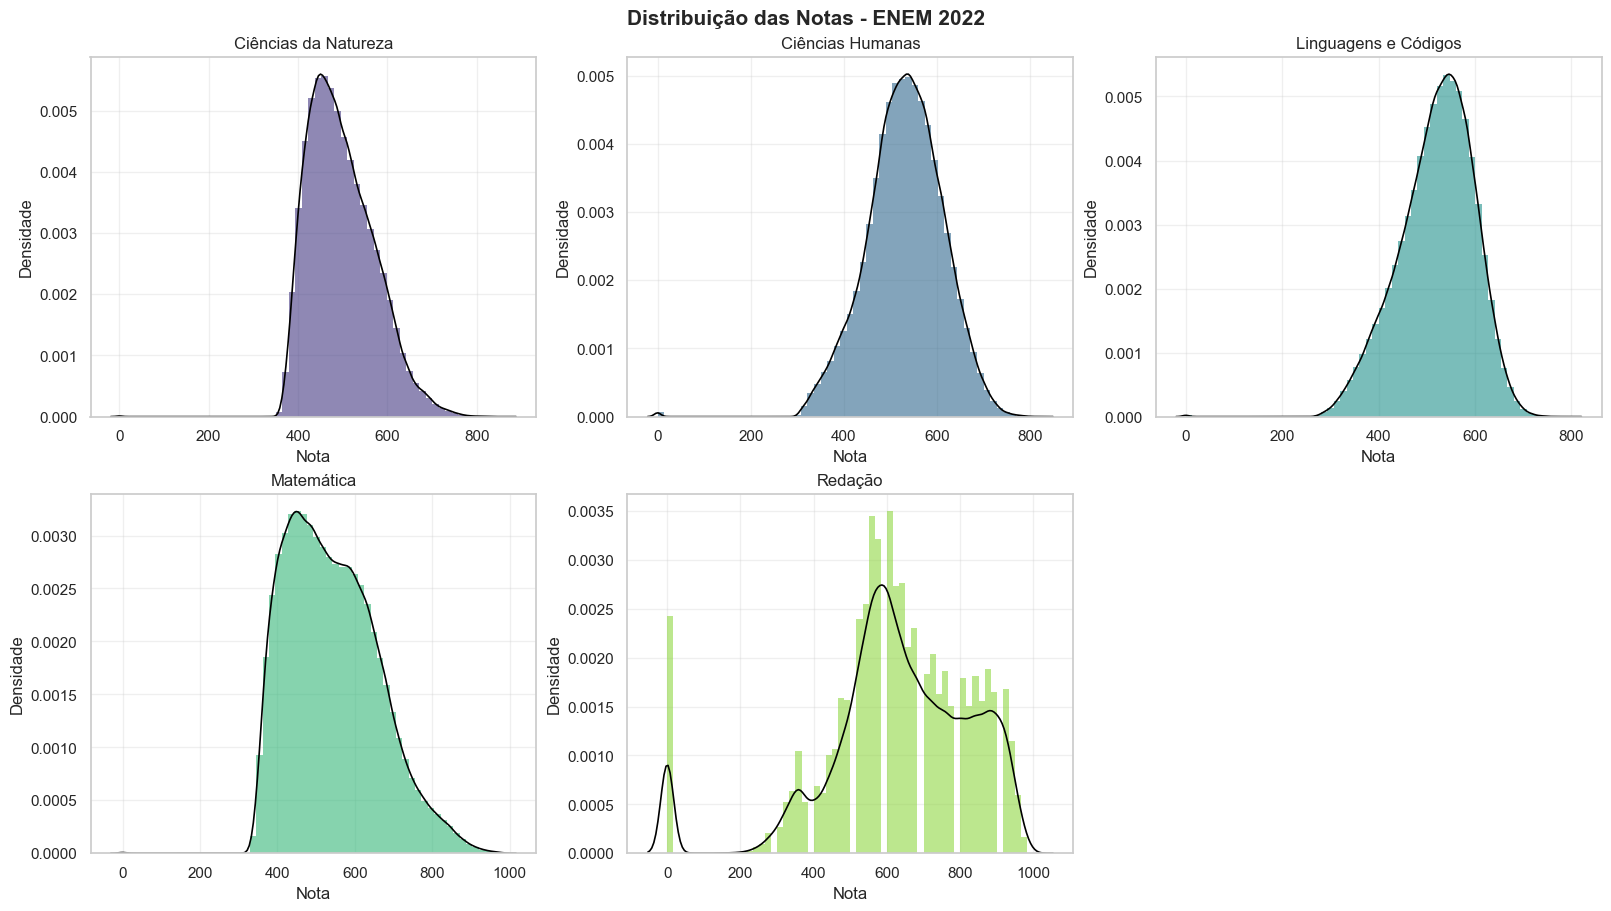

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for ax, nota in zip(axes.flat, NOTAS):
    dados = df[nota].dropna()
    sns.histplot(dados, bins=60, stat='density', color=PALETA_NOTAS[nota],
                 alpha=0.6, edgecolor='none', ax=ax)
    # KDE em amostra de 200 mil pontos (visualmente idêntica e muito mais rápida)
    amostra = dados.sample(min(len(dados), 200_000), random_state=42)
    sns.kdeplot(amostra, color='black', linewidth=1.2, ax=ax)
    ax.set_title(NOMES_NOTAS[nota])
    ax.set_xlabel('Nota')
    ax.set_ylabel('Densidade')
axes.flat[-1].axis('off')
fig.suptitle(f'Distribuição das Notas - ENEM {ANO}', fontsize=15, fontweight='bold')
salvar(fig, 'fig_01_distribuicao_notas')
plt.show()

In [6]:
def boxplots_por_grupo(dados, coluna, ordem, titulo, arquivo, rotacao=0):
    """Grid 2x3 com um boxplot por prova, agrupado pela coluna indicada."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    for ax, nota in zip(axes.flat, NOTAS):
        sns.boxplot(data=dados, x=coluna, y=nota, order=ordem,
                    color=COR_UNICA, showfliers=False, ax=ax)
        ax.set_title(NOMES_NOTAS[nota])
        ax.set_xlabel('')
        ax.set_ylabel('Nota')
        if rotacao:
            ax.tick_params(axis='x', rotation=rotacao)
    axes.flat[-1].axis('off')
    fig.suptitle(titulo, fontsize=15, fontweight='bold')
    salvar(fig, arquivo)
    plt.show()

Figura salva: ..\reports\figures\2022\fig_02_notas_por_escola.png


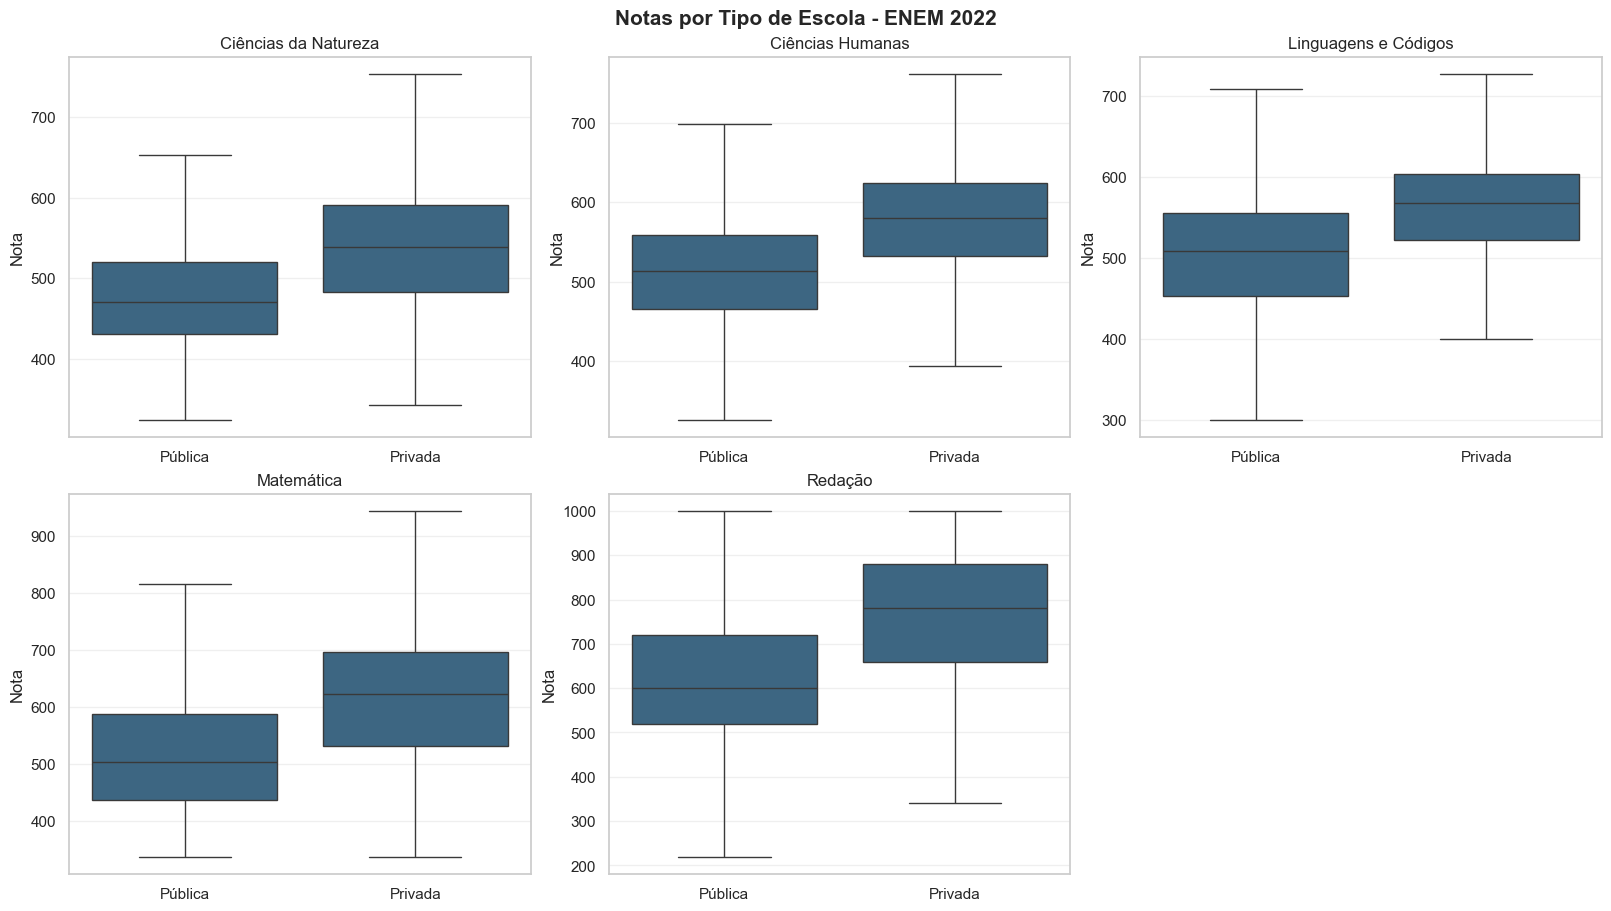

Medianas por Tipo de Escola:


,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Tipo_Escola_Label,,,,,
Privada,538.799988,579.700012,567.400024,621.400024,780.0
Pública,470.600006,513.099976,508.600006,503.399994,600.0


Diferença de Mediana (Privada - Pública):


Ciências da Natureza     68.199997
Ciências Humanas         66.599998
Linguagens e Códigos     58.799999
Matemática              118.000000
Redação                 180.000000
dtype: float32

In [7]:
publica_privada = df[df['Tipo_Escola_Label'].isin(['Pública', 'Privada'])]
boxplots_por_grupo(publica_privada, 'Tipo_Escola_Label', ['Pública', 'Privada'],
                   f'Notas por Tipo de Escola - ENEM {ANO}',
                   'fig_02_notas_por_escola')

medianas_escola = publica_privada.groupby('Tipo_Escola_Label')[NOTAS].median()
medianas_escola.columns = [NOMES_NOTAS[c] for c in medianas_escola.columns]
print('Medianas por Tipo de Escola:')
display(medianas_escola.round(1))
print('Diferença de Mediana (Privada - Pública):')
display((medianas_escola.loc['Privada'] - medianas_escola.loc['Pública']).round(1))

Figura salva: ..\reports\figures\2022\fig_02b_notas_por_dependencia_administrativa.png


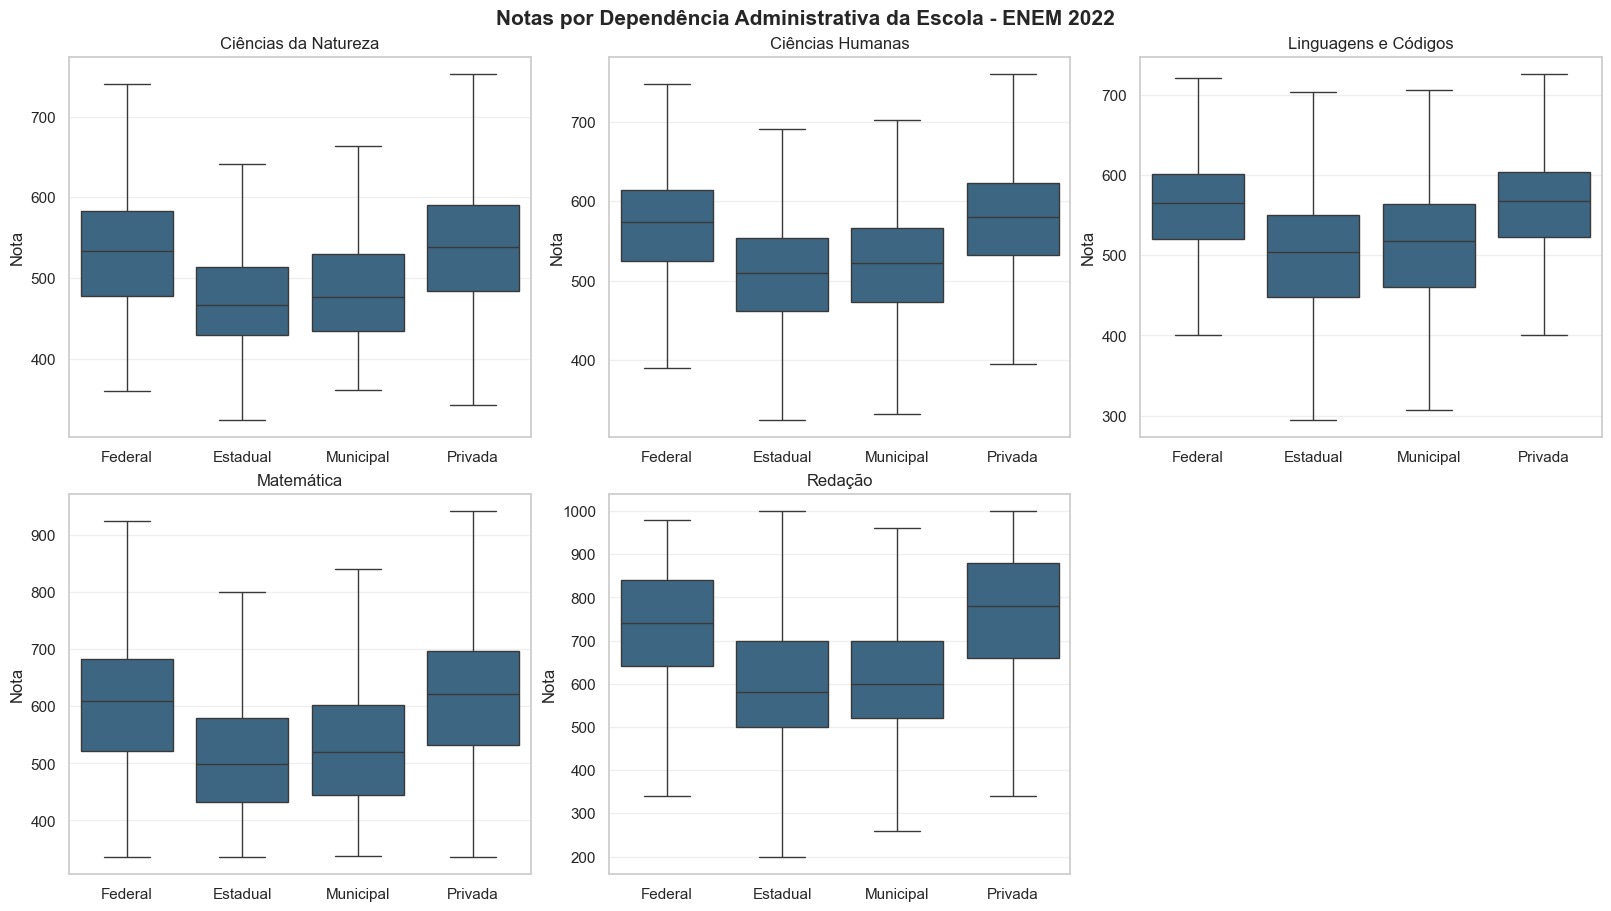

Medianas por Dependência Administrativa:


,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Dependencia_Adm_Label,,,,,
Federal,532.900024,573.500000,565.099976,608.700012,740.0
Estadual,467.100006,509.000000,504.600006,499.200012,580.0
Municipal,476.799988,521.900024,517.900024,520.400024,600.0
Privada,539.000000,579.599976,567.299988,621.700012,780.0


Diferença de Mediana (Federal - Municipal):


Ciências da Natureza     56.099998
Ciências Humanas         51.599998
Linguagens e Códigos     47.200001
Matemática               88.300003
Redação                 140.000000
dtype: float32

In [8]:
ordem_dep_adm = ['Federal', 'Estadual', 'Municipal', 'Privada']
boxplots_por_grupo(df.dropna(subset=['Dependencia_Adm_Label']), 'Dependencia_Adm_Label',
                   ordem_dep_adm, f'Notas por Dependência Administrativa da Escola - ENEM {ANO}',
                   'fig_02b_notas_por_dependencia_administrativa')

medianas_dep_adm = df.groupby('Dependencia_Adm_Label')[NOTAS].median().reindex(ordem_dep_adm)
medianas_dep_adm.columns = [NOMES_NOTAS[c] for c in medianas_dep_adm.columns]
print('Medianas por Dependência Administrativa:')
display(medianas_dep_adm.round(1))
print('Diferença de Mediana (Federal - Municipal):')
display((medianas_dep_adm.loc['Federal'] - medianas_dep_adm.loc['Municipal']).round(1))

Figura salva: ..\reports\figures\2022\fig_03_notas_por_raca.png


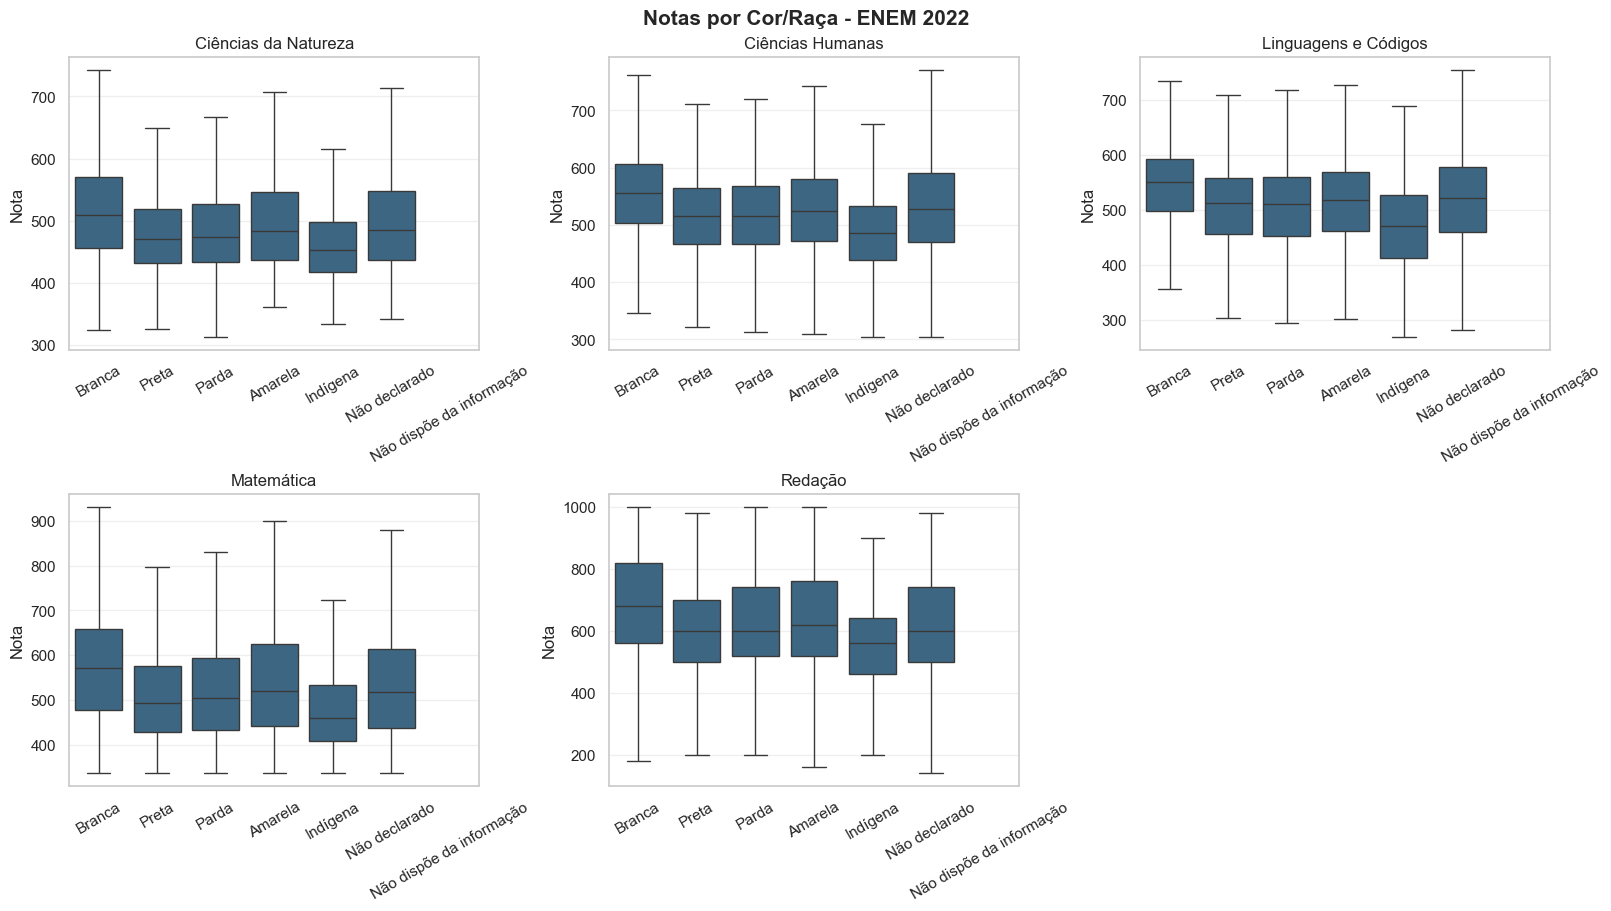

In [9]:
ordem_raca = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarado',
              'Não dispõe da informação']
boxplots_por_grupo(df, 'Cor_Raca_Label', ordem_raca,
                   f'Notas por Cor/Raça - ENEM {ANO}',
                   'fig_03_notas_por_raca', rotacao=30)

Figura salva: ..\reports\figures\2022\fig_04_notas_por_renda.png


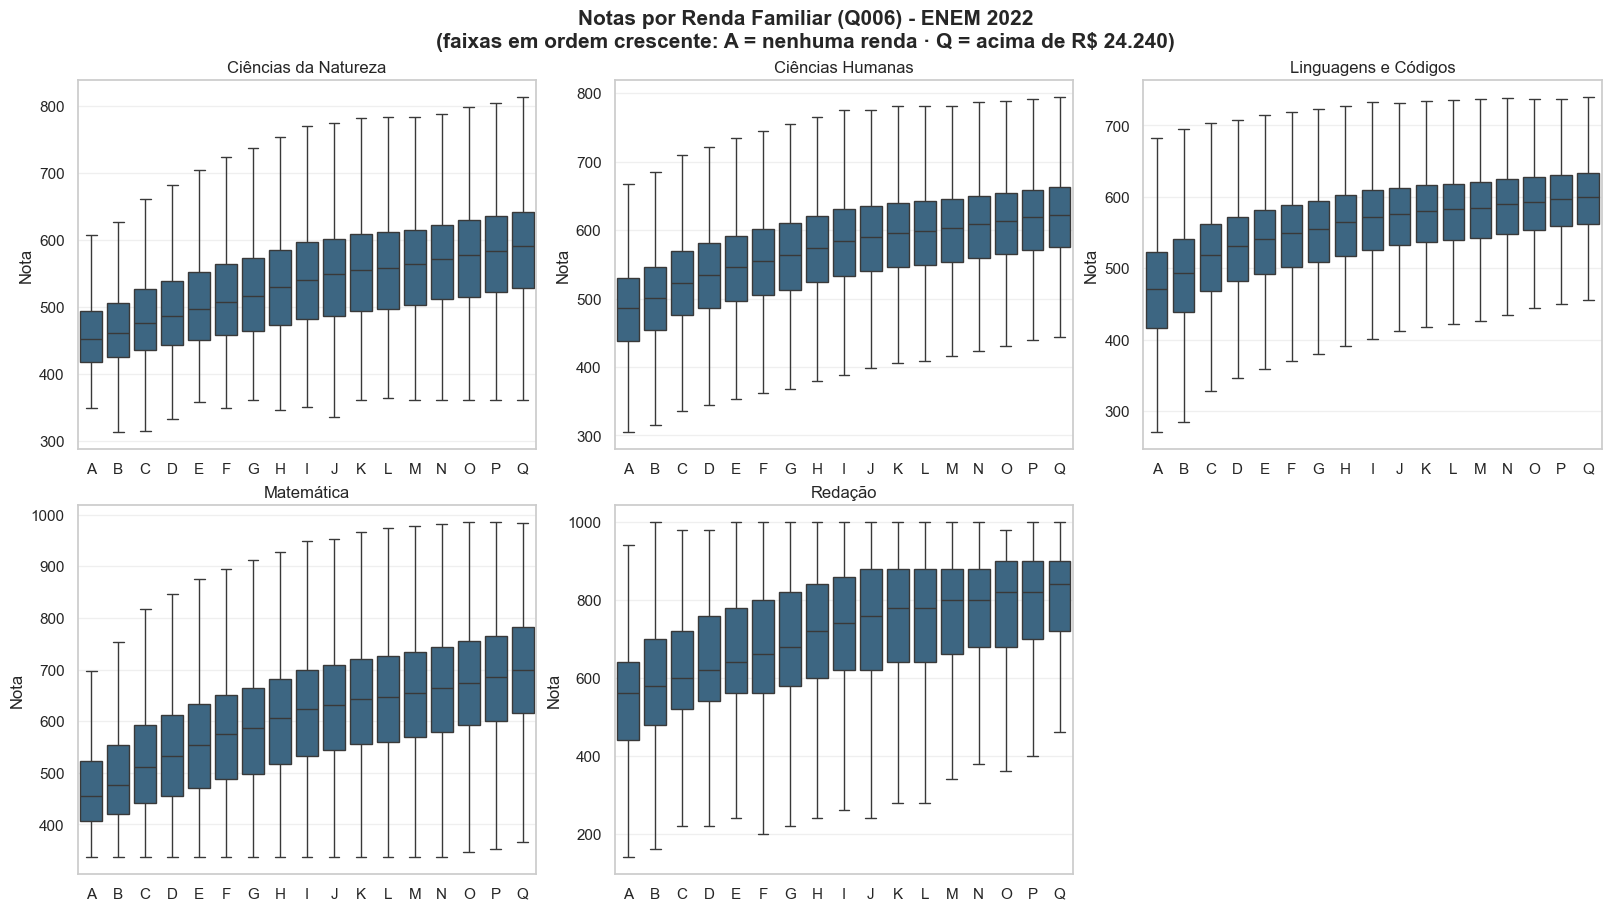

In [10]:
boxplots_por_grupo(
    df, 'Q6_Renda_Fam', ORDEM_Q6,
    f'Notas por Renda Familiar (Q006) - ENEM {ANO}\n'
    '(faixas em ordem crescente: A = nenhuma renda · Q = acima de R$ 24.240)',
    'fig_04_notas_por_renda')

Figura salva: ..\reports\figures\2022\fig_05_notas_por_escolaridade_mae.png


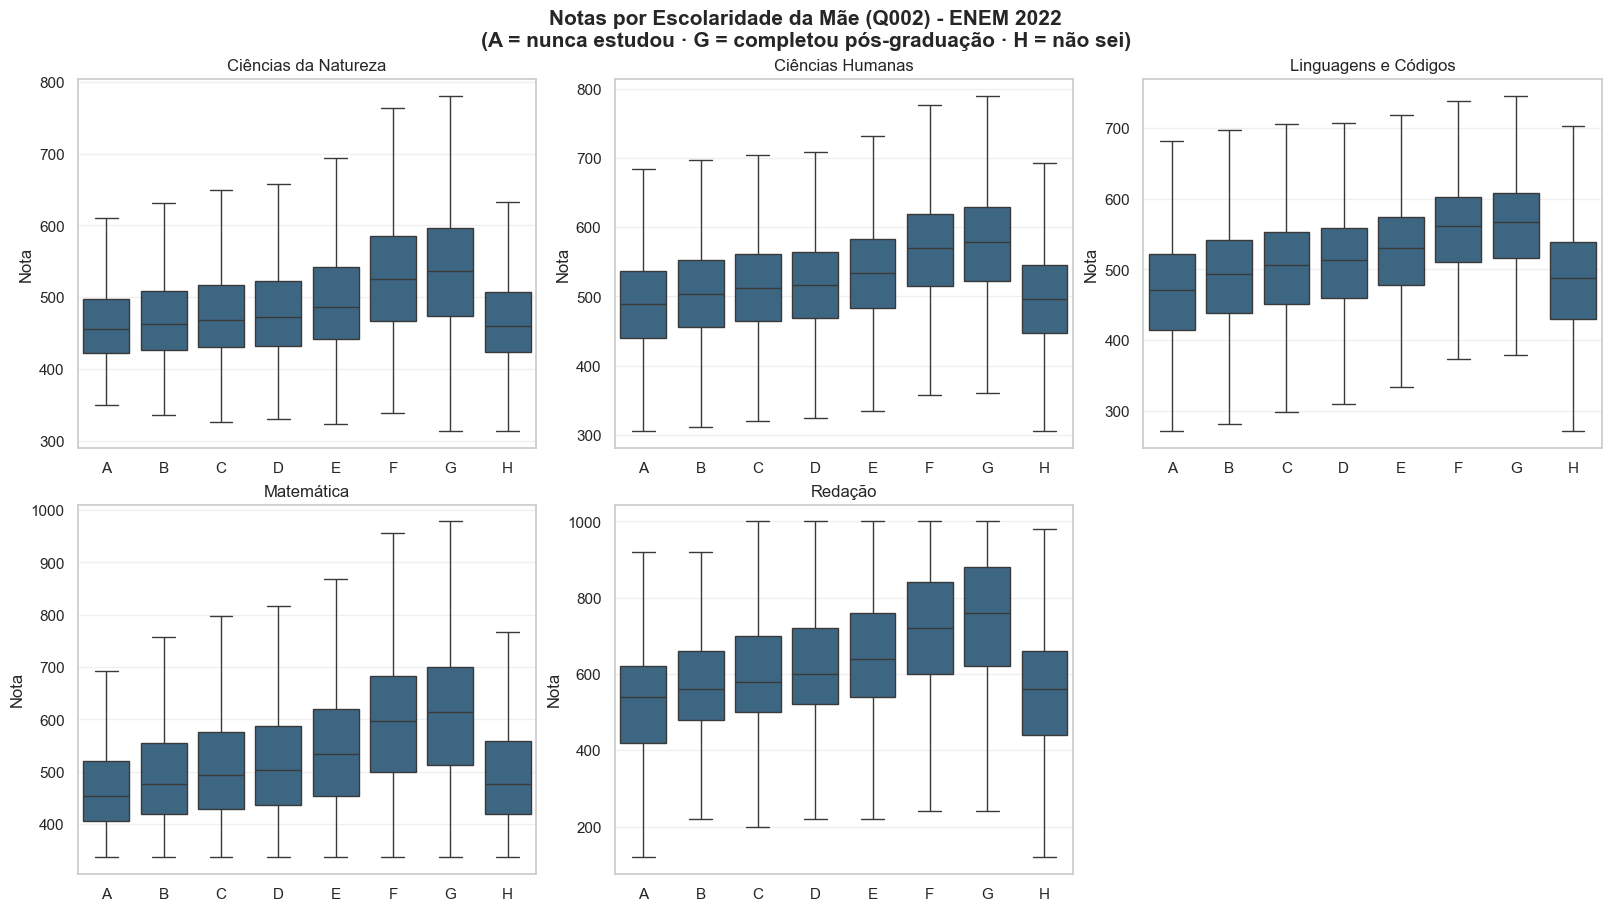

In [11]:
boxplots_por_grupo(
    df, 'Q2_Esc_Mae', ORDEM_Q2,
    f'Notas por Escolaridade da Mãe (Q002) - ENEM {ANO}\n'
    '(A = nunca estudou · G = completou pós-graduação · H = não sei)',
    'fig_05_notas_por_escolaridade_mae')

Figura salva: ..\reports\figures\2022\fig_06_notas_por_sexo.png


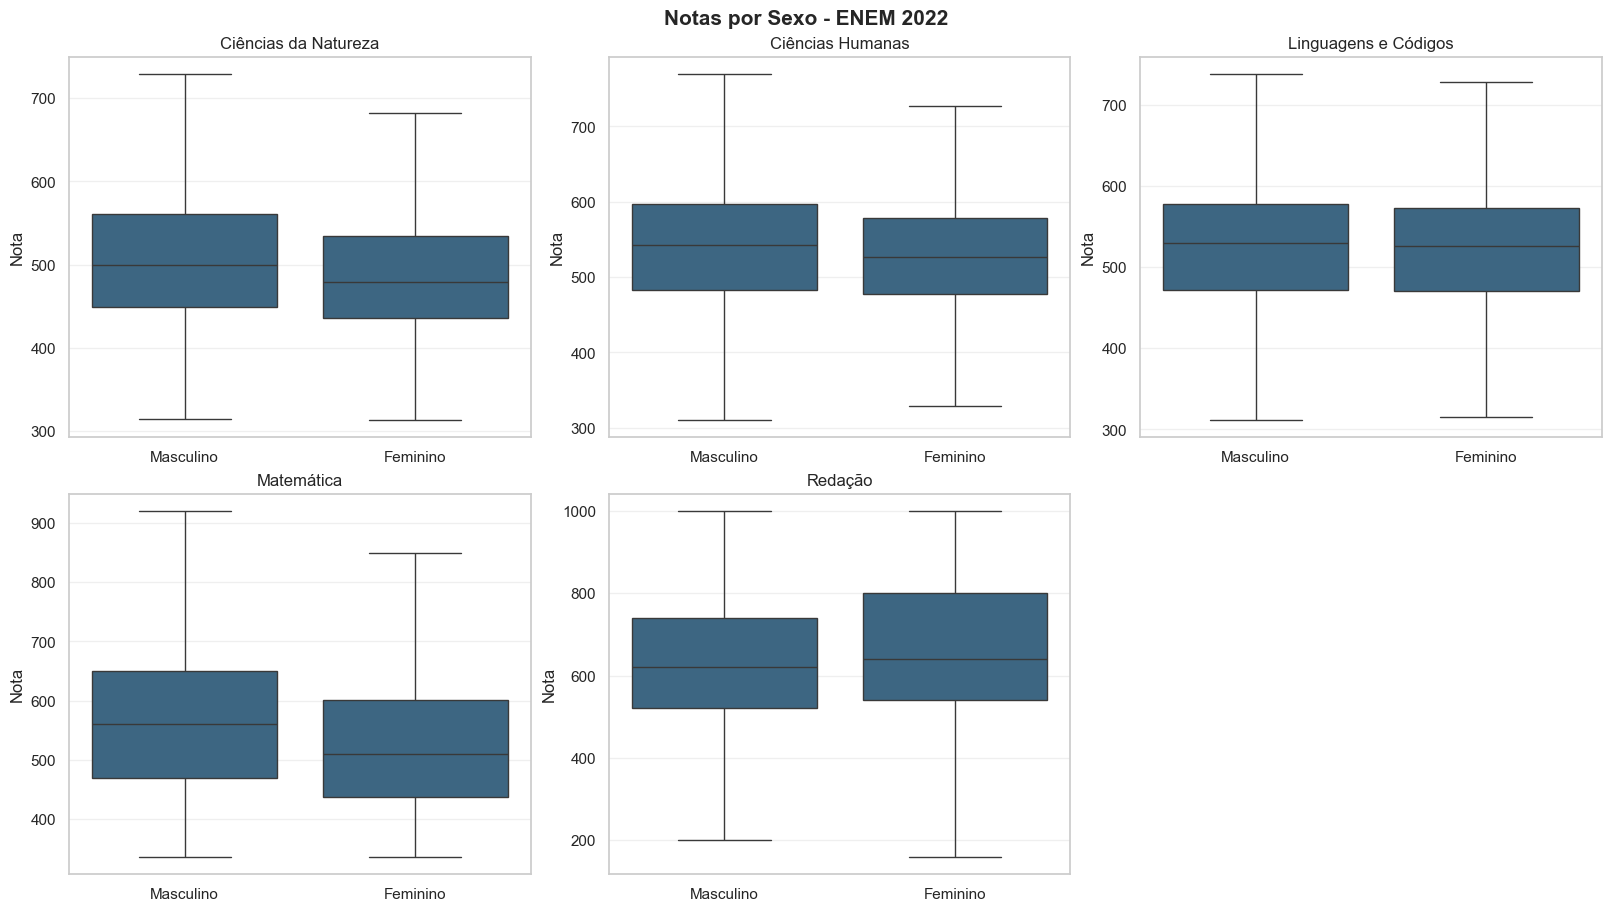

In [12]:
boxplots_por_grupo(df, 'Sexo_Label', ['Masculino', 'Feminino'],
                   f'Notas por Sexo - ENEM {ANO}',
                   'fig_06_notas_por_sexo')

Figura salva: ..\reports\figures\2022\fig_07_notas_por_computador_internet.png


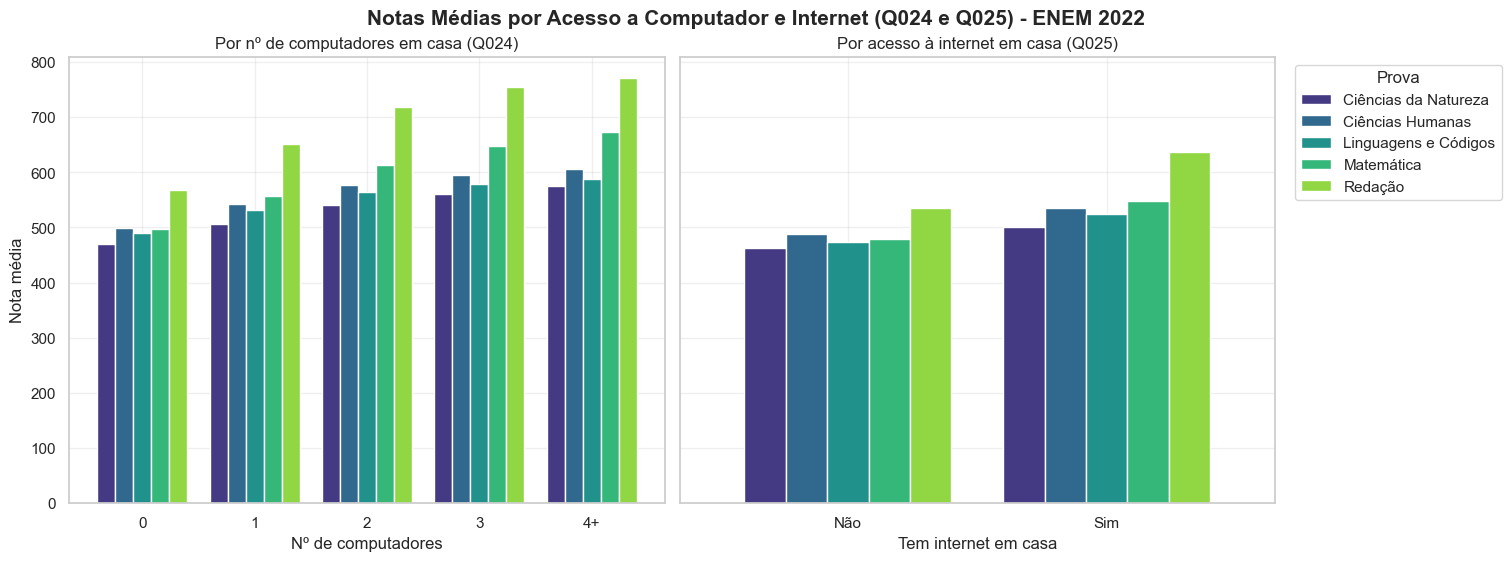

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)

medias_q24 = df.groupby(df['Q24_Computador'].map(MAPA_QTD))[NOTAS].mean().reindex(ORDEM_QTD)
medias_q24.columns = [NOMES_NOTAS[c] for c in medias_q24.columns]
medias_q24.plot(kind='bar', ax=axes[0], color=list(PALETA_NOTAS.values()),
                width=0.8, legend=False)
axes[0].set_title('Por nº de computadores em casa (Q024)')
axes[0].set_xlabel('Nº de computadores')
axes[0].set_ylabel('Nota média')
axes[0].tick_params(axis='x', rotation=0)

medias_q25 = df.groupby(df['Q25_Internet'].map(MAPA_Q25))[NOTAS].mean().reindex(['Não', 'Sim'])
medias_q25.columns = [NOMES_NOTAS[c] for c in medias_q25.columns]
medias_q25.plot(kind='bar', ax=axes[1], color=list(PALETA_NOTAS.values()), width=0.8)
axes[1].set_title('Por acesso à internet em casa (Q025)')
axes[1].set_xlabel('Tem internet em casa')
axes[1].legend(title='Prova', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle(f'Notas Médias por Acesso a Computador e Internet (Q024 e Q025) - ENEM {ANO}', fontsize=15, fontweight='bold')
salvar(fig, 'fig_07_notas_por_computador_internet')
plt.show()

## 4. Mapa - nota média geral por UF

O mapa coroplético é desenhado com matplotlib puro a partir do GeoJSON das UFs (`data/external/brazil_uf.geojson`). Caso o arquivo não exista, o código recorre a um gráfico de barras horizontais ordenado pelas médias.

Vale lembrar que `UF_Escola` só está preenchida para os candidatos com escola declarada; o mapa retrata, portanto, esse subconjunto.

Candidatos com UF da Escola Informada: 692,915
Figura salva: ..\reports\figures\2022\fig_08_mapa_media_geral_por_uf.png


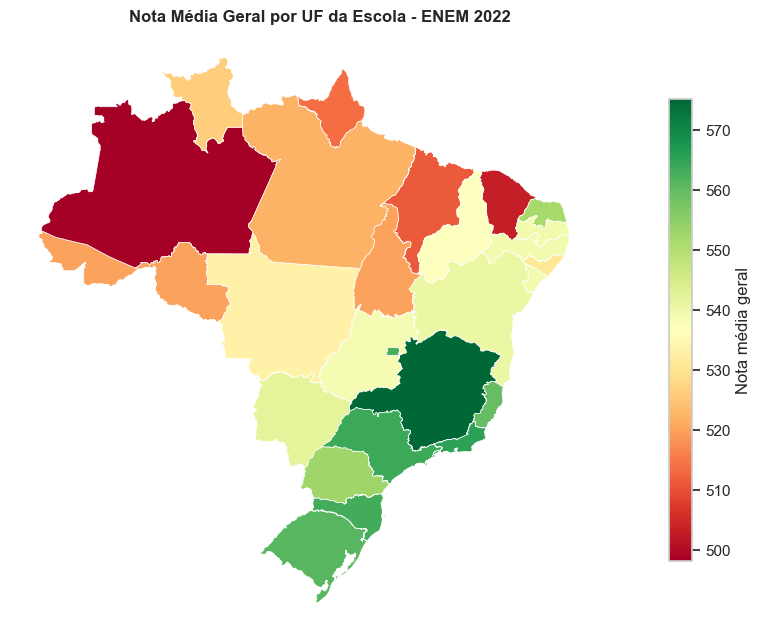

5 maiores médias por UF (da maior para a menor):
UF_Escola
MG    575.2
RJ    565.4
SP    563.8
SC    563.4
DF    562.6

5 menores médias por UF (da menor para a maior):
UF_Escola
AM    498.2
CE    503.1
MA    511.2
AP    513.6
TO    520.0


In [14]:
medias_uf = df.groupby('UF_Escola')['Nota_Media_Geral'].mean().dropna().sort_values()
print(f'Candidatos com UF da Escola Informada: {df["UF_Escola"].notna().sum():,}')

mapa_brasil = gpd.read_file(GEOJSON_PATH)
mapa_brasil['Media_Geral'] = mapa_brasil['sigla'].map(medias_uf)

fig, ax = plt.subplots(figsize=(10, 10))
mapa_brasil.plot(column='Media_Geral', cmap='RdYlGn', edgecolor='white', linewidth=0.5,
                 legend=True, legend_kwds={'label': 'Nota média geral', 'shrink': 0.6},
                 missing_kwds={'color': '#d9d9d9'}, ax=ax)
ax.axis('off')
ax.set_title(f'Nota Média Geral por UF da Escola - ENEM {ANO}', fontsize=12, fontweight='bold')
salvar(fig, 'fig_08_mapa_media_geral_por_uf')
plt.show()

print('5 maiores médias por UF (da maior para a menor):')
print(medias_uf.sort_values(ascending=False).head(5).astype(float).round(1).to_string())
print('\n5 menores médias por UF (da menor para a maior):')
print(medias_uf.head(5).astype(float).round(1).to_string())

## 5. Análise fragmentada - dando rosto aos dados

Aqui os números ganham concretude: comparamos a nota média geral entre grupos definidos pelo questionário socioeconômico - quem tem e quem não tem geladeira, computador ou banheiro em casa, faixas de renda e escolaridade da mãe.

Na comparação de banheiros, contrastamos quem não tem banheiro (`A`) com quem tem dois ou mais (`C`, `D`, `E`); pelo dicionário oficial, `A` indica ausência de banheiro, e não "um banheiro". Como referência para as faixas de renda, o salário mínimo de 2022 era R$ 1.212.

In [15]:
def media_e_n(filtro, nota='Nota_Media_Geral'):
    serie = df.loc[filtro, nota]
    return serie.mean(), len(serie)


def comparar(desc_a, filtro_a, desc_b, filtro_b):
    ma, na = media_e_n(filtro_a)
    mb, nb = media_e_n(filtro_b)
    print(f'Alunos {desc_a} tiraram em média {ma:.1f} pontos na média geral; '
          f'alunos {desc_b} tiraram {mb:.1f} - diferença de {abs(mb - ma):.1f} pontos. '
          f'(n = {na:,} vs {nb:,})\n')


# a) Geladeiras
comparar('sem geladeira em casa (Q012=A)',
         df['Q12_Geladeira'] == 'A',
         'com 2 ou mais geladeiras (Q012=C,D,E)',
         df['Q12_Geladeira'].isin(['C', 'D', 'E']))

# b) Computadores
comparar('sem computador em casa (Q024=A)',
         df['Q24_Computador'] == 'A',
         'com 2 ou mais computadores (Q024=C,D,E)',
         df['Q24_Computador'].isin(['C', 'D', 'E']))

# c) Banheiros (dicionário oficial: A = não tem banheiro)
comparar('sem banheiro em casa (Q008=A)',
         df['Q8_Banheiro'] == 'A',
         'com 2 ou mais banheiros (Q008=C,D,E)',
         df['Q8_Banheiro'].isin(['C', 'D', 'E']))

# d) Renda familiar (salário mínimo 2022 = R$ 1.212)
grupos_renda = [
    ('até 1 salário mínimo (Q006=A,B)', list('AB')),
    ('entre 1 e 5 salários mínimos (Q006=C-H)', list('CDEFGH')),
    ('entre 5 e 10 salários mínimos (Q006=I-M)', list('IJKLM')),
    ('mais de 10 salários mínimos (Q006=N-Q)', list('NOPQ')),
]
print('Renda familiar:')
medias_renda = []
for desc, letras in grupos_renda:
    m, n = media_e_n(df['Q6_Renda_Fam'].isin(letras))
    medias_renda.append(m)
    print(f'  Alunos com renda {desc}: média geral de {m:.1f} (n = {n:,})')
print(f'  → Diferença entre extremos: {medias_renda[-1] - medias_renda[0]:.1f} pontos.\n')

# e) Escolaridade da mãe
grupos_mae = [
    ('mãe que nunca estudou (Q002=A)', ['A']),
    ('mãe com ens. fundamental completo, sem ens. médio (Q002=D)', ['D']),
    ('mãe com ensino médio completo, sem faculdade (Q002=E)', ['E']),
    ('mãe com graduação ou pós (Q002=F,G)', ['F', 'G']),
]
print('Escolaridade da mãe:')
medias_mae = []
for desc, letras in grupos_mae:
    m, n = media_e_n(df['Q2_Esc_Mae'].isin(letras))
    medias_mae.append(m)
    print(f'  Alunos com {desc}: média geral de {m:.1f} (n = {n:,})')
print(f'  → Diferença entre extremos: {medias_mae[-1] - medias_mae[0]:.1f} pontos.')

Alunos sem geladeira em casa (Q012=A) tiraram em média 491.5 pontos na média geral; alunos com 2 ou mais geladeiras (Q012=C,D,E) tiraram 584.0 - diferença de 92.4 pontos. (n = 24,539 vs 105,960)

Alunos sem computador em casa (Q024=A) tiraram em média 505.0 pontos na média geral; alunos com 2 ou mais computadores (Q024=C,D,E) tiraram 613.3 - diferença de 108.3 pontos. (n = 853,162 vs 308,989)

Alunos sem banheiro em casa (Q008=A) tiraram em média 477.3 pontos na média geral; alunos com 2 ou mais banheiros (Q008=C,D,E) tiraram 581.6 - diferença de 104.3 pontos. (n = 12,024 vs 688,626)

Renda familiar:
  Alunos com renda até 1 salário mínimo (Q006=A,B): média geral de 500.1 (n = 655,956)
  Alunos com renda entre 1 e 5 salários mínimos (Q006=C-H): média geral de 551.8 (n = 1,031,713)
  Alunos com renda entre 5 e 10 salários mínimos (Q006=I-M): média geral de 616.3 (n = 156,460)
  Alunos com renda mais de 10 salários mínimos (Q006=N-Q): média geral de 646.1 (n = 83,624)
  → Diferença entre

Figura salva: ..\reports\figures\2022\fig_09_fragmentacao_geladeiras.png


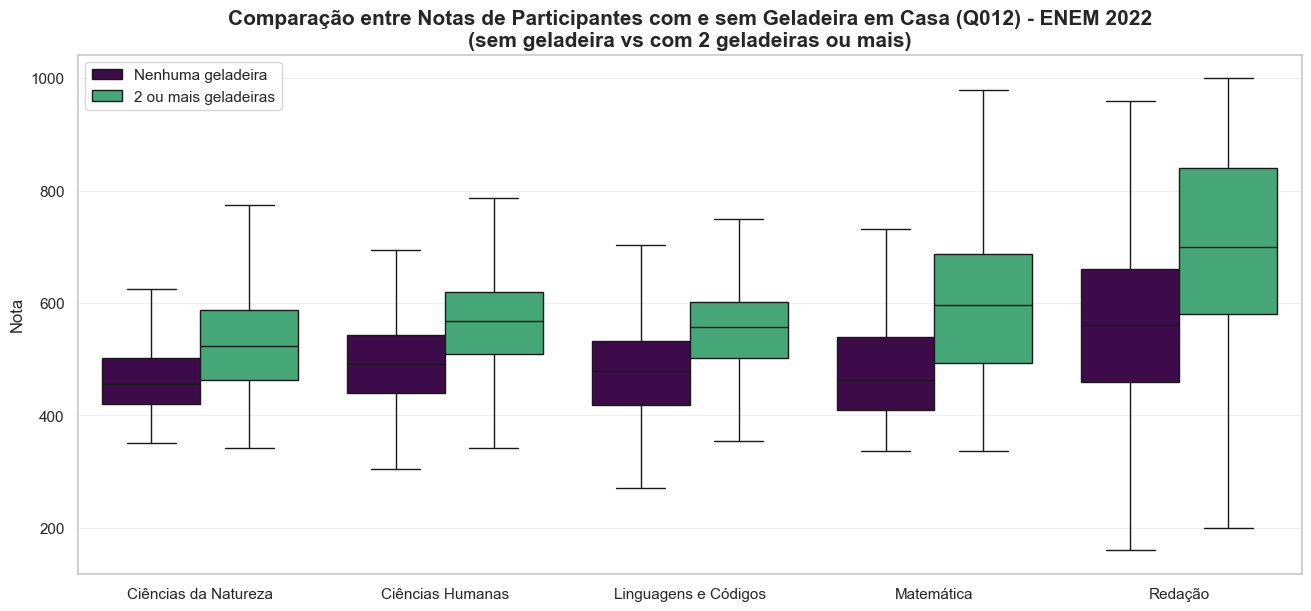

In [16]:
# Fragmentação: nenhuma geladeira vs 2 ou mais (Q012 C,D,E), mesmo recorte da comparação em texto
frag = pd.concat([
    df[df['Q12_Geladeira'] == 'A'].assign(Grupo='Nenhuma geladeira'),
    df[df['Q12_Geladeira'].isin(['C', 'D', 'E'])].assign(Grupo='2 ou mais geladeiras'),
])
longo = frag.melt(id_vars='Grupo', value_vars=NOTAS, var_name='Prova', value_name='Nota')
longo['Prova'] = longo['Prova'].map(NOMES_NOTAS)

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
sns.boxplot(data=longo, x='Prova', y='Nota', hue='Grupo',
            hue_order=['Nenhuma geladeira', '2 ou mais geladeiras'],
            palette=['#440154', '#35b779'], showfliers=False, ax=ax)
ax.set_title(f'Comparação entre Notas de Participantes com e sem Geladeira em Casa (Q012) - ENEM {ANO}\n'
             '(sem geladeira vs com 2 geladeiras ou mais)', fontsize=15, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nota')
ax.legend(title='')
salvar(fig, 'fig_09_fragmentacao_geladeiras')
plt.show()

## 6. Quais fatores têm maior relação com o desempenho? (Spearman)

Esta seção responde à pergunta de pesquisa: medimos a força da relação de cada fator socioeconômico com o desempenho pela correlação de Spearman e ordenamos os fatores pelo |ρ| com a média geral das cinco notas.

A escolha de Spearman, e não Pearson, se deve à natureza ordinal das questões do questionário: as respostas seguem uma ordem natural (A < B < C…), preservada na codificação (A=0, B=1, …). Categorias sem ordem, como "Não sei" e "Não declarado", viram `NaN` e ficam fora do cálculo.

Uma consequência dessa deleção par a par é que o **n varia de fator para fator**: renda familiar usa quase toda a base, enquanto tipo de escola usa apenas quem declarou escola pública ou privada - majoritariamente concluintes do ensino médio, já que "Não respondeu" é a categoria mais comum. Por transparência, a célula imprime o n de cada fator junto da tabela de correlações.

Cor/raça e dependência administrativa da escola não entram no ranking: são variáveis nominais com três ou mais categorias, e atribuir-lhes uma ordem numérica seria arbitrário, distorcendo a interpretação do ρ. Variáveis binárias, por outro lado, entram normalmente - com apenas duas categorias, a codificação 0/1 não impõe ordem falsa (o resultado equivale a uma correlação ponto-bisserial).

Codificações: tipo de escola (Pública=0, Privada=1) e sexo (M=0, F=1).

In [17]:
ESCALA = {letra: pos for pos, letra in enumerate('ABCDEFGHIJKLMNOPQ')}


def codificar_ordinal(serie, validas):
    """Letra -> posição ordinal; valores fora de `validas` (ex.: 'Não sei') viram NaN."""
    return serie.map({letra: ESCALA[letra] for letra in validas})


explicativas = pd.DataFrame({
    'Escolaridade do pai (Q1)': codificar_ordinal(df['Q1_Esc_Pai'], 'ABCDEFG'),    # H = Não sei
    'Escolaridade da mãe (Q2)': codificar_ordinal(df['Q2_Esc_Mae'], 'ABCDEFG'),    # H = Não sei
    'Ocupação do pai (Q3)': codificar_ordinal(df['Q3_Ocup_Pai'], 'ABCDE'),         # F = Não sei
    'Ocupação da mãe (Q4)': codificar_ordinal(df['Q4_Ocup_Mae'], 'ABCDE'),         # F = Não sei
    'Pessoas na residência (Q5)': pd.to_numeric(df['Q5_Pessoas_Resid'], errors='coerce'),
    'Renda familiar (Q6)': codificar_ordinal(df['Q6_Renda_Fam'], 'ABCDEFGHIJKLMNOPQ'),
    'Nº de banheiros (Q8)': codificar_ordinal(df['Q8_Banheiro'], 'ABCDE'),
    'Nº de geladeiras (Q12)': codificar_ordinal(df['Q12_Geladeira'], 'ABCDE'),
    'Nº de computadores (Q24)': codificar_ordinal(df['Q24_Computador'], 'ABCDE'),
    'Tem internet (Q25)': codificar_ordinal(df['Q25_Internet'], 'AB'),
    'Tipo de escola (Pública=0, Privada=1)': df['Tipo_Escola'].map({2: 0, 3: 1}),
    'Sexo (M=0, F=1)': df['Sexo'].map({'M': 0, 'F': 1}),
})

correlacoes = pd.DataFrame({
    NOMES_NOTAS[nota]: explicativas.corrwith(df[nota], method='spearman')
    for nota in ['Nota_Media_Geral'] + NOTAS
})

# Ranking que responde à pergunta de pesquisa: fatores ordenados pelo |ρ| com a média geral
correlacoes = correlacoes.loc[correlacoes['Média Geral'].abs().sort_values(ascending=False).index]

# Transparência: cada linha usa só os candidatos com o fator preenchido (deleção par a par)
print('n usado em cada correlação (candidatos com o fator preenchido):')
print(explicativas.notna().sum().reindex(correlacoes.index).map('{:,}'.format).to_string())

correlacoes.round(3)

n usado em cada correlação (candidatos com o fator preenchido):
Renda familiar (Q6)                      1,927,753
Nº de computadores (Q24)                 1,927,753
Tipo de escola (Pública=0, Privada=1)      957,731
Ocupação do pai (Q3)                     1,702,960
Escolaridade do pai (Q1)                 1,750,362
Ocupação da mãe (Q4)                     1,762,707
Escolaridade da mãe (Q2)                 1,872,352
Nº de banheiros (Q8)                     1,927,753
Tem internet (Q25)                       1,927,753
Nº de geladeiras (Q12)                   1,927,753
Pessoas na residência (Q5)               1,927,753
Sexo (M=0, F=1)                          1,927,753


,Média Geral,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Renda familiar (Q6),0.467,0.378,0.412,0.415,0.427,0.341
Nº de computadores (Q24),0.435,0.363,0.396,0.392,0.383,0.316
"Tipo de escola (Pública=0, Privada=1)",0.407,0.323,0.344,0.318,0.334,0.359
Ocupação do pai (Q3),0.391,0.311,0.341,0.359,0.342,0.298
Escolaridade do pai (Q1),0.376,0.294,0.313,0.331,0.327,0.302
Ocupação da mãe (Q4),0.374,0.296,0.322,0.338,0.325,0.292
Escolaridade da mãe (Q2),0.368,0.283,0.296,0.312,0.318,0.308
Nº de banheiros (Q8),0.338,0.278,0.288,0.286,0.304,0.268
Tem internet (Q25),0.198,0.146,0.170,0.188,0.171,0.146
Nº de geladeiras (Q12),0.123,0.103,0.107,0.107,0.117,0.090


Figura salva: ..\reports\figures\2022\fig_10_heatmap_correlacoes.png


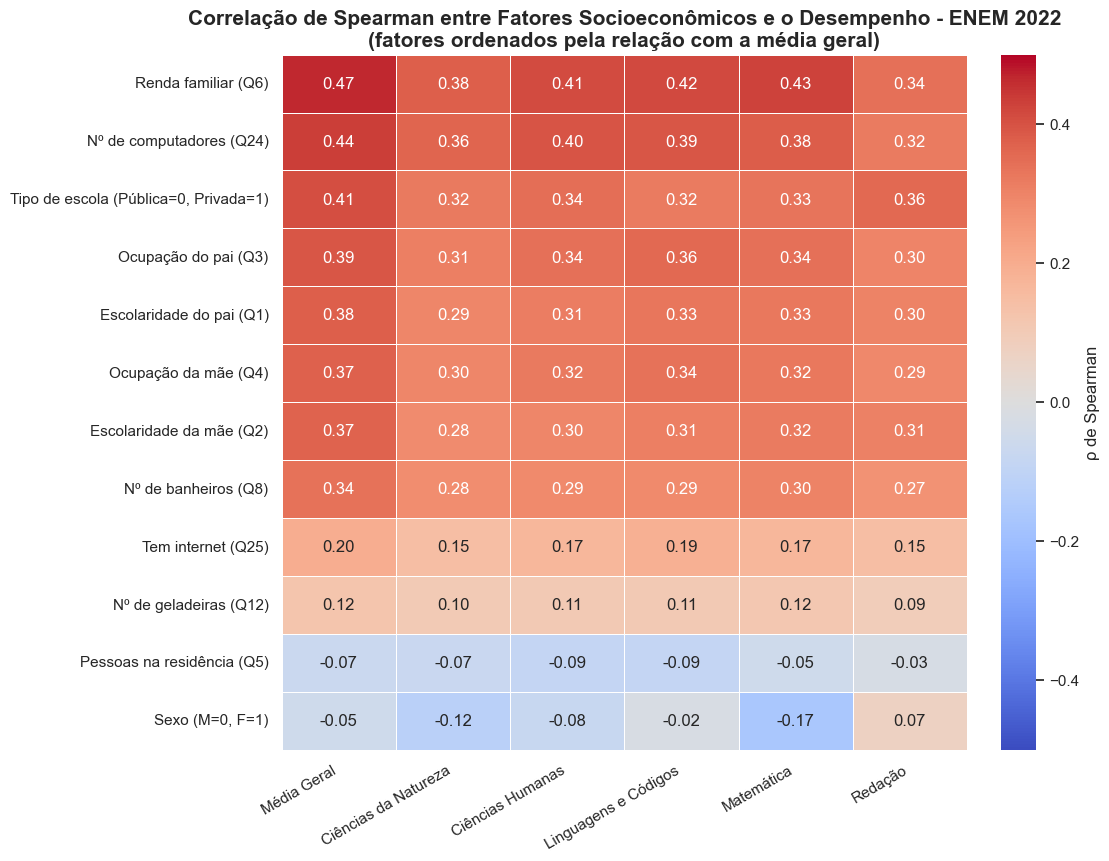

In [18]:
fig, ax = plt.subplots(figsize=(11, 8.5), constrained_layout=True)
sns.heatmap(correlacoes, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'ρ de Spearman'}, ax=ax)
ax.set_title(f'Correlação de Spearman entre Fatores Socioeconômicos e o Desempenho - ENEM {ANO}\n'
             f'(fatores ordenados pela relação com a média geral)', fontsize=15, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
salvar(fig, 'fig_10_heatmap_correlacoes')
plt.show()

Figura salva: ..\reports\figures\2022\fig_11_ranking_fatores_media_geral.png


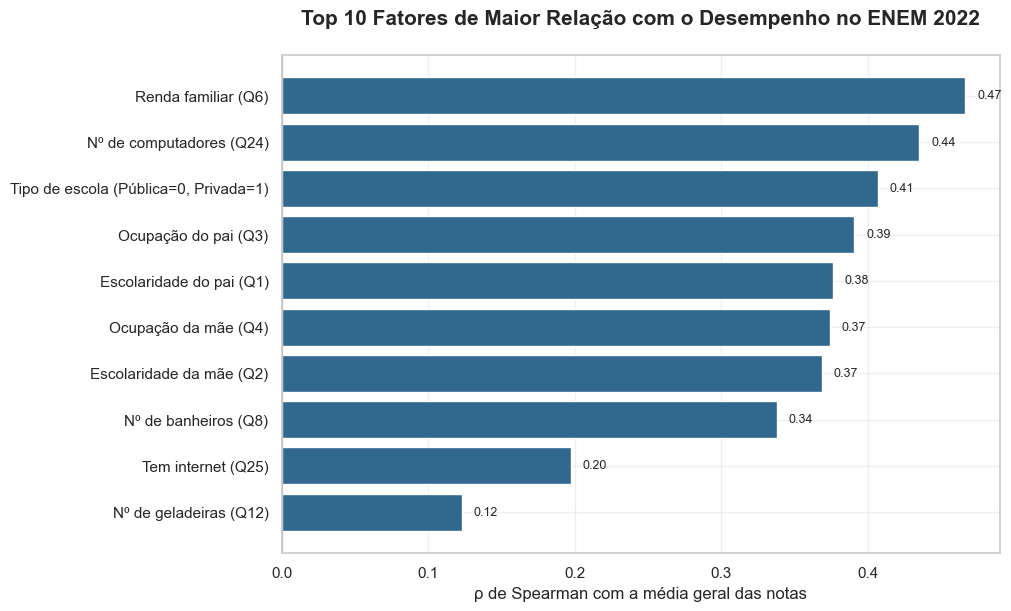

In [19]:
# Resposta à pergunta de pesquisa: fatores com maior |ρ| com a média geral das 5 notas
rank_geral = correlacoes['Média Geral'].abs().sort_values(ascending=False).head(10)
valores = correlacoes.loc[rank_geral.index, 'Média Geral'].iloc[::-1]  # invertido p/ barh

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
ax.barh(valores.index, valores.values, color=COR_UNICA)
for i, v in enumerate(valores.values):
    ax.text(v + (0.008 if v >= 0 else -0.008), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title(f'Top 10 Fatores de Maior Relação com o Desempenho no ENEM {ANO}\n', fontsize=15, fontweight='bold')
ax.set_xlabel('ρ de Spearman com a média geral das notas')
salvar(fig, 'fig_11_ranking_fatores_media_geral')
plt.show()

## 7. Achados de 2022

A célula a seguir calcula e imprime os números-chave deste ano a partir dos dados já processados nas seções anteriores. A síntese comparando todos os anos está em `analise_consolidada_edicoes_enem.ipynb`.

In [20]:
top3 = correlacoes['Média Geral'].abs().sort_values(ascending=False).head(3)
print('- Fatores de maior relação com o desempenho: '
      + '; '.join(f'{fator} (ρ = {correlacoes.loc[fator, "Média Geral"]:.2f})'
                  for fator in top3.index) + '.')

geral_pub = df.loc[df['Tipo_Escola'] == 2, 'Nota_Media_Geral'].mean()
geral_priv = df.loc[df['Tipo_Escola'] == 3, 'Nota_Media_Geral'].mean()
print(f'- Média geral, escola pública vs privada: {geral_pub:.1f} vs {geral_priv:.1f} '
      f'- diferença de {geral_priv - geral_pub:.1f} pontos '
      f'({(geral_priv / geral_pub - 1) * 100:.0f}% a mais na privada).')

renda_baixa = df.loc[df['Q6_Renda_Fam'].isin(['A', 'B']), 'Nota_Media_Geral'].mean()
renda_alta = df.loc[df['Q6_Renda_Fam'].isin(['N', 'O', 'P', 'Q']), 'Nota_Media_Geral'].mean()
print(f'- Renda até 1 salário mínimo vs mais de 10 salários mínimos: {renda_baixa:.1f} vs {renda_alta:.1f} '
      f'- diferença de {renda_alta - renda_baixa:.1f} pontos.')

mae_a = df.loc[df['Q2_Esc_Mae'] == 'A', 'Nota_Media_Geral'].mean()
mae_fg = df.loc[df['Q2_Esc_Mae'].isin(['F', 'G']), 'Nota_Media_Geral'].mean()
print(f'- Mãe que nunca estudou vs mãe com graduação/pós: '
      f'{mae_a:.1f} vs {mae_fg:.1f} - diferença de {mae_fg - mae_a:.1f} pontos.')

net_nao = df.loc[df['Q25_Internet'] == 'A', 'Nota_Media_Geral'].mean()
net_sim = df.loc[df['Q25_Internet'] == 'B', 'Nota_Media_Geral'].mean()
print(f'- Sem internet vs com internet em casa: {net_nao:.1f} vs {net_sim:.1f} '
      f'- diferença de {net_sim - net_nao:.1f} pontos.')

gel_0 = df.loc[df['Q12_Geladeira'] == 'A', 'Nota_Media_Geral'].mean()
gel_2 = df.loc[df['Q12_Geladeira'].isin(['C', 'D', 'E']), 'Nota_Media_Geral'].mean()
print(f'- Sem geladeira vs 2+ geladeiras: {gel_0:.1f} vs {gel_2:.1f} '
      f'- diferença de {gel_2 - gel_0:.1f} pontos.')

uf_top = medias_uf.idxmax()
uf_bottom = medias_uf.idxmin()
print(f'- UF com maior média geral: {uf_top} ({medias_uf.max():.1f}); '
      f'menor: {uf_bottom} ({medias_uf.min():.1f}) '
      f'- diferença de {medias_uf.max() - medias_uf.min():.1f} pontos.')

- Fatores de maior relação com o desempenho: Renda familiar (Q6) (ρ = 0.47); Nº de computadores (Q24) (ρ = 0.44); Tipo de escola (Pública=0, Privada=1) (ρ = 0.41).
- Média geral, escola pública vs privada: 518.9 vs 608.4 - diferença de 89.4 pontos (17% a mais na privada).
- Renda até 1 salário mínimo vs mais de 10 salários mínimos: 500.1 vs 646.1 - diferença de 146.0 pontos.
- Mãe que nunca estudou vs mãe com graduação/pós: 478.1 vs 594.7 - diferença de 116.5 pontos.
- Sem internet vs com internet em casa: 487.6 vs 548.8 - diferença de 61.2 pontos.
- Sem geladeira vs 2+ geladeiras: 491.5 vs 584.0 - diferença de 92.4 pontos.
- UF com maior média geral: MG (575.2); menor: AM (498.2) - diferença de 77.0 pontos.
